# Bruker WTX Kidney To AnnData

This notebook is intentionally RAM-conscious.

It is optimized for the job that matters for KaroSpace:

1. Inspect the raw Bruker WTX inputs with compact metadata tables.
2. Build a sparse `.h5ad` in chunks.
3. Optionally run lighter-weight downstream analysis on a smaller subset.

The raw files currently point at:

- `/Users/christoffer/Downloads/bruker-wtx-data/kidney_metadata_file.csv.gz`
- `/Users/christoffer/Downloads/bruker-wtx-data/kidney_exprMat_file.csv.gz`

The expression CSV is large, so the notebook avoids dense full-matrix loading and avoids storing unnecessary metadata columns in the final `AnnData`.


In [1]:
from __future__ import annotations

import gc
import gzip
import json
import os
from pathlib import Path

os.environ.setdefault("KMP_WARNINGS", "0")
os.environ.setdefault("NUMBA_CACHE_DIR", str(Path.cwd() / ".numba_cache"))
os.environ.setdefault("NUMBA_DISABLE_JIT", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse

ad.settings.allow_write_nullable_strings = True

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

ROOT = Path.cwd().resolve()
METADATA_PATH = Path("/Users/christoffer/Downloads/bruker-wtx-data/kidney_metadata_file.csv.gz")
EXPR_PATH = Path("/Users/christoffer/Downloads/bruker-wtx-data/kidney_exprMat_file.csv.gz")
OUTPUT_DIR = ROOT / "data" / "processed" / "bruker-wtx-kidney"
OUTPUT_PATH = OUTPUT_DIR / "bruker-wtx-kidney.h5ad"

CHUNKSIZE = 100_000
SELECT_FOVS = None
MAX_CELLS = 100_000_000
WRITE_OUTPUT = True

RUN_ANALYSIS = True
ANALYSIS_MAX_CELLS = 100_000_000
ANALYSIS_INPUT_MODE = "reload_if_available"
LEIDEN_RESOLUTION = 0.6
KMEANS_CLUSTERS = 12

ROOT, METADATA_PATH.exists(), EXPR_PATH.exists(), OUTPUT_PATH

(PosixPath('/Users/christoffer/work/karolinska/development/KaroSpaceDataWrangling/notebooks'),
 True,
 True,
 PosixPath('/Users/christoffer/work/karolinska/development/KaroSpaceDataWrangling/notebooks/data/processed/bruker-wtx-kidney/bruker-wtx-kidney.h5ad'))

## Compact metadata configuration

Only a narrow set of metadata columns is loaded into memory and carried into the final `.h5ad`. This keeps the export practical while still preserving the fields that are useful for KaroSpace filtering and sanity checks.


In [2]:
METADATA_COLUMNS = [
    "fov",
    "slide_ID",
    "cell_ID",
    "Run_name",
    "Run_Tissue_name",
    "Panel",
    "assay_type",
    "nCount_RNA",
    "nFeature_RNA",
    "nCount_negprobes",
    "nFeature_negprobes",
    "nCount_falsecode",
    "nFeature_falsecode",
    "Area.um2",
    "CenterX_global_px",
    "CenterY_global_px",
]

NUMERIC_INT_COLUMNS = [
    "fov",
    "slide_ID",
    "cell_ID",
    "nCount_RNA",
    "nFeature_RNA",
    "nCount_negprobes",
    "nFeature_negprobes",
    "nCount_falsecode",
    "nFeature_falsecode",
]

NUMERIC_FLOAT_COLUMNS = [
    "Area.um2",
    "CenterX_global_px",
    "CenterY_global_px",
]

CATEGORY_COLUMNS = [
    "Run_name",
    "Run_Tissue_name",
    "Panel",
    "assay_type",
]


In [3]:
def read_expr_gene_columns(expr_path: Path) -> list[str]:
    with gzip.open(expr_path, "rt") as handle:
        header = handle.readline().rstrip("\n").split(",")
    return [c for c in header if c not in {"fov", "cell_ID"}]


def load_metadata_table(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path, compression="gzip", usecols=METADATA_COLUMNS)

    for col in NUMERIC_INT_COLUMNS:
        if col in meta.columns:
            meta[col] = pd.to_numeric(meta[col], errors="coerce").astype("Int32")

    for col in NUMERIC_FLOAT_COLUMNS:
        if col in meta.columns:
            meta[col] = pd.to_numeric(meta[col], errors="coerce").astype("float32")

    for col in CATEGORY_COLUMNS:
        if col in meta.columns:
            meta[col] = meta[col].astype("category")

    return meta


metadata = load_metadata_table(METADATA_PATH)
gene_cols = read_expr_gene_columns(EXPR_PATH)

print("metadata shape:", metadata.shape)
print("metadata columns:", metadata.columns.tolist())
print("gene columns:", len(gene_cols))

metadata.head()


metadata shape: (436787, 16)
metadata columns: ['fov', 'Run_name', 'Run_Tissue_name', 'Panel', 'assay_type', 'slide_ID', 'cell_ID', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 'nFeature_falsecode', 'Area.um2', 'CenterX_global_px', 'CenterY_global_px']
gene columns: 20378


,fov,Run_name,Run_Tissue_name,Panel,assay_type,slide_ID,cell_ID,nCount_RNA,nFeature_RNA,nCount_negprobes,nFeature_negprobes,nCount_falsecode,nFeature_falsecode,Area.um2,CenterX_global_px,CenterY_global_px
0,1,Run0,S0,WTx,RNA,1,1,287,190,1,1,2,2,77.198402,21193.0,115981.0
1,1,Run0,S0,WTx,RNA,1,2,1069,720,0,0,2,2,100.180801,21223.0,115928.0
2,1,Run0,S0,WTx,RNA,1,3,1134,747,3,2,4,4,81.950401,20977.0,115894.0
3,1,Run0,S0,WTx,RNA,1,4,557,375,0,0,4,4,96.695999,21049.0,115883.0
4,1,Run0,S0,WTx,RNA,1,5,57,45,0,0,2,2,25.646400,20935.0,115892.0


In [4]:
summary_cols = [
    "fov",
    "slide_ID",
    "Run_name",
    "Run_Tissue_name",
    "Panel",
    "assay_type",
    "nCount_RNA",
    "nFeature_RNA",
    "CenterX_global_px",
    "CenterY_global_px",
]

metadata[summary_cols].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fov,436787.0,<NA>,<NA>,<NA>,167.868098,113.361266,1.0,69.0,145.0,261.0,396.0
slide_ID,436787.0,<NA>,<NA>,<NA>,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Run_name,436787,1,Run0,436787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Run_Tissue_name,436787,1,S0,436787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Panel,436787,1,WTx,436787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
assay_type,436787,1,RNA,436787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nCount_RNA,436787.0,<NA>,<NA>,<NA>,1471.843345,1481.567664,5.0,497.0,965.0,1886.0,17300.0
nFeature_RNA,436787.0,<NA>,<NA>,<NA>,912.273621,784.108429,1.0,357.0,664.0,1216.0,7245.0
CenterX_global_px,436787.0,NaN,NaN,NaN,31826.886719,16398.048828,354.0,18531.0,30107.0,42883.0,72312.0
CenterY_global_px,436787.0,NaN,NaN,NaN,61481.710938,33008.246094,-4231.0,34407.0,65883.0,88554.5,119148.0


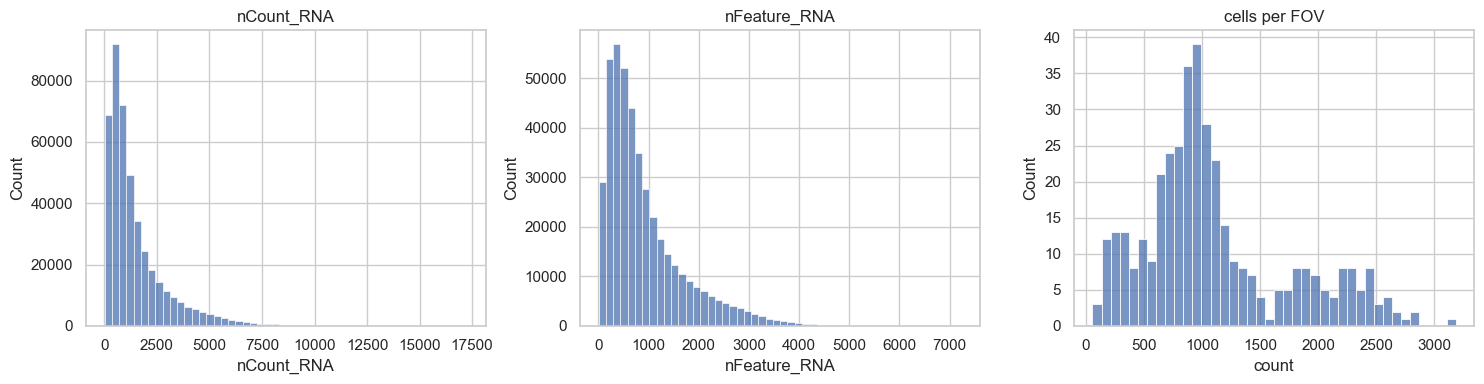

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(metadata["nCount_RNA"].dropna().astype(float), bins=50, ax=axes[0])
axes[0].set_title("nCount_RNA")

sns.histplot(metadata["nFeature_RNA"].dropna().astype(float), bins=50, ax=axes[1])
axes[1].set_title("nFeature_RNA")

fov_sizes = metadata["fov"].value_counts(dropna=True).sort_index()
sns.histplot(fov_sizes.astype(float), bins=40, ax=axes[2])
axes[2].set_title("cells per FOV")

plt.tight_layout()
plt.show()


## Sparse assembly helpers

The final export path is designed to minimize memory pressure:

- metadata is compact and typed
- only a small set of `obs` columns is kept
- expression is read in chunks
- each chunk is converted directly to sparse CSR
- no duplicate count layers are created by default


In [6]:
EXPORT_OBS_COLUMNS = [
    "fov",
    "slide_ID",
    "cell_ID",
    "Run_name",
    "Run_Tissue_name",
    "Panel",
    "assay_type",
    "sample_id",
    "section_id",
    "dataset_id",
    "nCount_RNA",
    "nFeature_RNA",
    "nCount_negprobes",
    "nFeature_negprobes",
    "nCount_falsecode",
    "nFeature_falsecode",
    "Area.um2",
    "CenterX_global_px",
    "CenterY_global_px",
]


def make_obs_key_from_arrays(fov: pd.Series, cell_id: pd.Series) -> pd.Index:
    return fov.astype(str).str.strip() + "__" + cell_id.astype(str).str.strip()


def sanitize_obs_for_h5ad(obs_df: pd.DataFrame) -> pd.DataFrame:
    out = obs_df.copy()
    for col in out.columns:
        ser = out[col]
        if isinstance(ser.dtype, pd.CategoricalDtype):
            continue
        if pd.api.types.is_object_dtype(ser) or pd.api.types.is_string_dtype(ser):
            out[col] = ser.astype("string")
    return out


def normalize_total_inplace(adata: ad.AnnData, target_sum: float = 10_000) -> None:
    if sparse.issparse(adata.X):
        if not sparse.isspmatrix_csr(adata.X):
            adata.X = adata.X.tocsr()
        counts = np.asarray(adata.X.sum(axis=1)).ravel().astype(np.float32)
        counts[counts == 0] = 1.0
        scale = target_sum / counts
        adata.X = sparse.diags(scale) @ adata.X
    else:
        counts = np.asarray(adata.X.sum(axis=1)).ravel().astype(np.float32)
        counts[counts == 0] = 1.0
        adata.X = adata.X * (target_sum / counts)[:, None]

    adata.obs["total_counts_before_normalization"] = counts
    adata.obs["normalization_target_sum"] = float(target_sum)


def prepare_metadata_for_export(metadata_df: pd.DataFrame) -> pd.DataFrame:
    obs = metadata_df.copy()
    obs["obs_key"] = make_obs_key_from_arrays(obs["fov"], obs["cell_ID"])
    if obs["obs_key"].duplicated().any():
        dupes = int(obs["obs_key"].duplicated().sum())
        raise ValueError(f"metadata has {dupes} duplicated fov/cell_ID keys")

    obs["dataset_id"] = pd.Categorical(["bruker-wtx-kidney"] * len(obs))
    obs["sample_id"] = obs["Run_Tissue_name"].astype("string").fillna("kidney").astype("category")
    obs["section_id"] = (
        "fov_" + obs["fov"].astype("Int32").astype(str).str.zfill(3)
    ).astype("category")

    return obs.set_index("obs_key", drop=True)


def build_sparse_anndata(
    expr_path: Path,
    metadata_indexed: pd.DataFrame,
    *,
    chunksize: int = 2_000,
    select_fovs: list[int] | None = None,
    max_cells: int | None = None,
) -> ad.AnnData:
    genes = read_expr_gene_columns(expr_path)
    matrices = []
    obs_parts = []
    gene_nnz = np.zeros(len(genes), dtype=np.int64)
    gene_sum = np.zeros(len(genes), dtype=np.int64)
    kept_cells = 0

    for chunk_idx, chunk in enumerate(
        pd.read_csv(
            expr_path,
            compression="gzip",
            chunksize=chunksize,
            dtype={"fov": "Int32", "cell_ID": "Int32"},
        ),
        start=1,
    ):
        if select_fovs is not None:
            chunk = chunk[chunk["fov"].isin(select_fovs)].copy()
        if chunk.empty:
            continue

        if max_cells is not None:
            remaining = max_cells - kept_cells
            if remaining <= 0:
                break
            chunk = chunk.iloc[:remaining].copy()

        obs_keys = make_obs_key_from_arrays(chunk["fov"], chunk["cell_ID"])
        missing = ~obs_keys.isin(metadata_indexed.index)
        if missing.any():
            sample_missing = pd.DataFrame(
                {"fov": chunk.loc[missing, "fov"], "cell_ID": chunk.loc[missing, "cell_ID"]}
            ).head(10)
            raise ValueError(f"missing metadata for some expression rows:\n{sample_missing}")

        obs_chunk = metadata_indexed.loc[obs_keys, EXPORT_OBS_COLUMNS].copy()
        obs_chunk.index = pd.Index(obs_keys.to_numpy(), name="obs_key")

        values = chunk[genes].to_numpy(dtype=np.int32, copy=False)
        gene_nnz += (values != 0).sum(axis=0)
        gene_sum += values.sum(axis=0)

        matrices.append(sparse.csr_matrix(values))
        obs_parts.append(obs_chunk)
        kept_cells += len(obs_chunk)

        print(f"chunk {chunk_idx}: kept {len(obs_chunk):,} cells; cumulative {kept_cells:,}")

        del chunk, obs_keys, obs_chunk, values
        gc.collect()

    if not matrices:
        raise ValueError("no expression rows selected; check SELECT_FOVS / MAX_CELLS")

    X = sparse.vstack(matrices, format="csr")
    obs = sanitize_obs_for_h5ad(pd.concat(obs_parts, axis=0))

    var = pd.DataFrame(index=pd.Index(genes, name="gene"))
    var["feature_name"] = var.index.astype(str)
    var["feature_type"] = "gene"
    var["n_cells_by_counts"] = gene_nnz
    var["total_counts"] = gene_sum

    nonzero_gene_mask = var["n_cells_by_counts"].to_numpy() > 0
    if not np.all(nonzero_gene_mask):
        X = X[:, nonzero_gene_mask]
        var = var.loc[nonzero_gene_mask].copy()

    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.obsm["spatial"] = adata.obs[["CenterX_global_px", "CenterY_global_px"]].to_numpy(dtype=np.float32)
    adata.uns["dataset_source"] = {
        "metadata_path": str(METADATA_PATH),
        "expression_path": str(expr_path),
        "chunksize": int(chunksize),
        "selected_fovs": None if select_fovs is None else [int(x) for x in select_fovs],
        "max_cells": None if max_cells is None else int(max_cells),
        "ram_profile": "compact-metadata sparse-chunk-build",
    }
    adata.uns["karospace_hints"] = {
        "section_key": "section_id",
        "sample_key": "sample_id",
        "spatial_key": "spatial",
        "notes": [
            "raw Bruker WTX export does not include curated cell-type labels",
            "the main KaroSpace-ready path is build + write; optional analysis is separate",
        ],
    }
    return adata


In [7]:
metadata_indexed = prepare_metadata_for_export(metadata)
metadata_indexed[EXPORT_OBS_COLUMNS].head()


,fov,slide_ID,cell_ID,Run_name,Run_Tissue_name,Panel,assay_type,sample_id,section_id,dataset_id,nCount_RNA,nFeature_RNA,nCount_negprobes,nFeature_negprobes,nCount_falsecode,nFeature_falsecode,Area.um2,CenterX_global_px,CenterY_global_px
obs_key,,,,,,,,,,,,,,,,,,,
1__1,1,1,1,Run0,S0,WTx,RNA,S0,fov_001,bruker-wtx-kidney,287,190,1,1,2,2,77.198402,21193.0,115981.0
1__2,1,1,2,Run0,S0,WTx,RNA,S0,fov_001,bruker-wtx-kidney,1069,720,0,0,2,2,100.180801,21223.0,115928.0
1__3,1,1,3,Run0,S0,WTx,RNA,S0,fov_001,bruker-wtx-kidney,1134,747,3,2,4,4,81.950401,20977.0,115894.0
1__4,1,1,4,Run0,S0,WTx,RNA,S0,fov_001,bruker-wtx-kidney,557,375,0,0,4,4,96.695999,21049.0,115883.0
1__5,1,1,5,Run0,S0,WTx,RNA,S0,fov_001,bruker-wtx-kidney,57,45,0,0,2,2,25.646400,20935.0,115892.0


## Preview build

The notebook defaults are conservative on purpose:

- `CHUNKSIZE = 2_000`
- `MAX_CELLS = 25_000`
- `WRITE_OUTPUT = False`

For the final full export, set `MAX_CELLS = None`.


In [8]:
adata = build_sparse_anndata(
    EXPR_PATH,
    metadata_indexed,
    chunksize=CHUNKSIZE,
    select_fovs=SELECT_FOVS,
    max_cells=MAX_CELLS,
)

adata


chunk 1: kept 100,000 cells; cumulative 100,000
chunk 2: kept 100,000 cells; cumulative 200,000
chunk 3: kept 100,000 cells; cumulative 300,000
chunk 4: kept 100,000 cells; cumulative 400,000
chunk 5: kept 36,787 cells; cumulative 436,787


AnnData object with n_obs × n_vars = 436787 × 20378
    obs: 'fov', 'slide_ID', 'cell_ID', 'Run_name', 'Run_Tissue_name', 'Panel', 'assay_type', 'sample_id', 'section_id', 'dataset_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 'nFeature_falsecode', 'Area.um2', 'CenterX_global_px', 'CenterY_global_px'
    var: 'feature_name', 'feature_type', 'n_cells_by_counts', 'total_counts'
    uns: 'dataset_source', 'karospace_hints'
    obsm: 'spatial'

In [9]:
print("obs x vars:", adata.n_obs, adata.n_vars)
print("X format:", type(adata.X), "nnz:", adata.X.nnz)
print("obsm keys:", list(adata.obsm.keys()))
print("obs columns:", len(adata.obs.columns))
print("var columns:", len(adata.var.columns))

adata.obs.head()


obs x vars: 436787 20378
X format: <class 'scipy.sparse._csr.csr_matrix'> nnz: 401230762
obsm keys: ['spatial']
obs columns: 19
var columns: 4


,fov,slide_ID,cell_ID,Run_name,Run_Tissue_name,Panel,assay_type,sample_id,section_id,dataset_id,nCount_RNA,nFeature_RNA,nCount_negprobes,nFeature_negprobes,nCount_falsecode,nFeature_falsecode,Area.um2,CenterX_global_px,CenterY_global_px
obs_key,,,,,,,,,,,,,,,,,,,
17__1,17,1,1,Run0,S0,WTx,RNA,S0,fov_017,bruker-wtx-kidney,1037,824,1,1,4,4,161.913605,42848.0,114876.0
17__2,17,1,2,Run0,S0,WTx,RNA,S0,fov_017,bruker-wtx-kidney,1360,991,0,0,4,3,332.020813,43652.0,114822.0
17__3,17,1,3,Run0,S0,WTx,RNA,S0,fov_017,bruker-wtx-kidney,82,62,0,0,0,0,77.817596,46238.0,114880.0
17__4,17,1,4,Run0,S0,WTx,RNA,S0,fov_017,bruker-wtx-kidney,820,638,0,0,2,2,240.494400,42721.0,114822.0
17__5,17,1,5,Run0,S0,WTx,RNA,S0,fov_017,bruker-wtx-kidney,18,13,2,1,0,0,79.704002,44786.0,114839.0


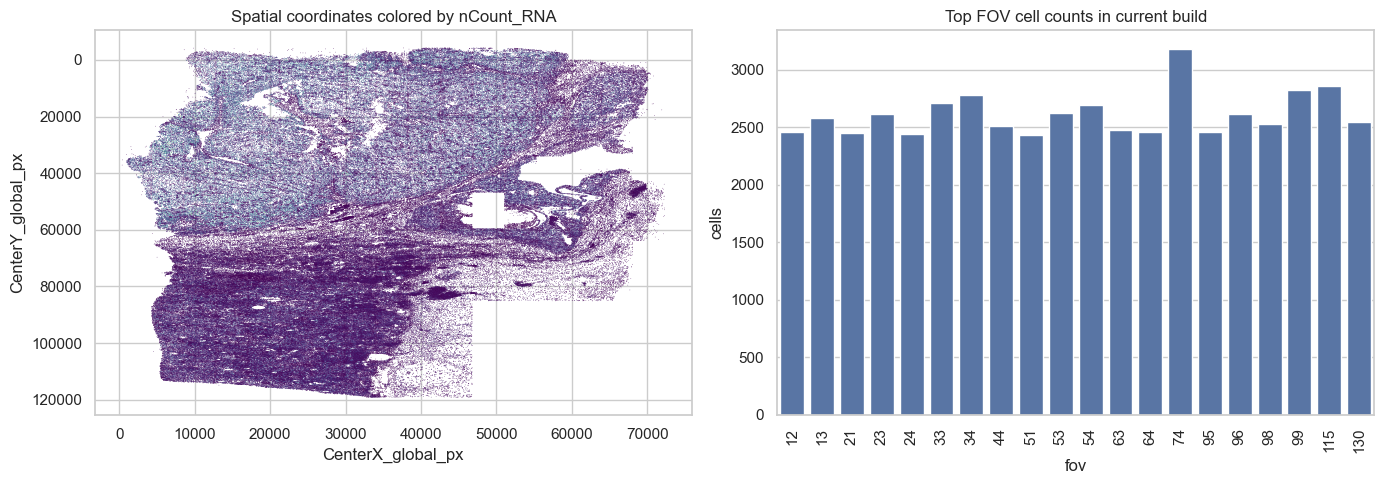

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    adata.obsm["spatial"][:, 0],
    adata.obsm["spatial"][:, 1],
    s=0.2,
    c=adata.obs["nCount_RNA"].astype(float).to_numpy(),
    cmap="viridis",
    linewidths=0,
)
axes[0].set_title("Spatial coordinates colored by nCount_RNA")
axes[0].set_xlabel("CenterX_global_px")
axes[0].set_ylabel("CenterY_global_px")
axes[0].invert_yaxis()

top_fovs = adata.obs["fov"].value_counts().head(20).sort_index()
sns.barplot(x=top_fovs.index.astype(str), y=top_fovs.values, ax=axes[1], color="#4c72b0")
axes[1].set_title("Top FOV cell counts in current build")
axes[1].set_xlabel("fov")
axes[1].set_ylabel("cells")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


In [13]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
adata.write(OUTPUT_PATH)

## Optional lighter analysis

This section is off by default because it is much more RAM-hungry than the export path.

If you want exploratory clustering:

- set `RUN_ANALYSIS = True`
- keep `ANALYSIS_MAX_CELLS` at a moderate size first
- prefer `ANALYSIS_INPUT_MODE = "reload_if_available"` once you have written the `.h5ad`
- Leiden is preferred; KMeans is used as a fallback if `leidenalg` is unavailable
- only after that consider a larger run


## Analysis input

Use the already-written `.h5ad` as the default analysis source when it exists. That way you can restart the kernel and continue from the compact saved file instead of rebuilding from the raw CSVs.


In [11]:
if ANALYSIS_INPUT_MODE not in {"reload_if_available", "reload_only", "memory_only"}:
    raise ValueError("ANALYSIS_INPUT_MODE must be one of: reload_if_available, reload_only, memory_only")

if ANALYSIS_INPUT_MODE in {"reload_if_available", "reload_only"} and OUTPUT_PATH.exists():
    analysis_input = ad.read_h5ad(OUTPUT_PATH)
    analysis_input_source = f"reloaded from {OUTPUT_PATH}"
elif ANALYSIS_INPUT_MODE == "reload_only":
    raise FileNotFoundError(f"requested reload_only, but no file exists at {OUTPUT_PATH}")
elif "adata" in globals():
    analysis_input = adata
    analysis_input_source = "using in-memory adata from the build step"
else:
    raise RuntimeError("no analysis input available; build or reload the .h5ad first")

print(analysis_input_source)
analysis_input


using in-memory adata from the build step


AnnData object with n_obs × n_vars = 436787 × 20378
    obs: 'fov', 'slide_ID', 'cell_ID', 'Run_name', 'Run_Tissue_name', 'Panel', 'assay_type', 'sample_id', 'section_id', 'dataset_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 'nFeature_falsecode', 'Area.um2', 'CenterX_global_px', 'CenterY_global_px'
    var: 'feature_name', 'feature_type', 'n_cells_by_counts', 'total_counts'
    uns: 'dataset_source', 'karospace_hints'
    obsm: 'spatial'

In [14]:
if RUN_ANALYSIS:
    try:
        import scanpy as sc
    except Exception as exc:
        print(f"scanpy import failed: {exc!r}")
        analysis_adata = None
    else:
        analysis_adata = (
            analysis_input[:ANALYSIS_MAX_CELLS].copy()
            if ANALYSIS_MAX_CELLS is not None
            else analysis_input.copy()
        )
        analysis_adata.var_names_make_unique()
        sc.pp.calculate_qc_metrics(analysis_adata, percent_top=None, log1p=False, inplace=True)
        sc.pp.filter_genes(analysis_adata, min_cells=10)
        normalize_total_inplace(analysis_adata, target_sum=10_000)
        sc.pp.log1p(analysis_adata)
        sc.pp.highly_variable_genes(
            analysis_adata,
            flavor="seurat",
            n_top_genes=min(2_000, analysis_adata.n_vars),
        )
        analysis_adata = analysis_adata[:, analysis_adata.var["highly_variable"]].copy()
        sc.tl.pca(analysis_adata, svd_solver="arpack")
        sc.pp.neighbors(analysis_adata)
        sc.tl.umap(analysis_adata)
        analysis_adata
else:
    analysis_adata = None
    print("RUN_ANALYSIS is False; skipping memory-heavier scanpy workflow.")


/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: divide by zero encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: overflow encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: invalid value encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:737: RuntimeWarning: divide by zero encountered in matmul
  matmat=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:737: RuntimeWarning: overflow encountered in matmul
  matmat=lambda x: X @ x - 

In [15]:
if RUN_ANALYSIS and analysis_adata is not None:
    cluster_key = "cluster"
    try:
        import leidenalg  # noqa: F401
    except Exception:
        from sklearn.cluster import KMeans

        n_clusters = max(2, min(KMEANS_CLUSTERS, analysis_adata.n_obs // 20))
        labels = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit_predict(
            analysis_adata.obsm["X_pca"]
        )
        analysis_adata.obs[cluster_key] = pd.Categorical(labels.astype(str))
        cluster_method = f"kmeans_{n_clusters}"
    else:
        sc.tl.leiden(analysis_adata, resolution=LEIDEN_RESOLUTION, key_added=cluster_key)
        cluster_method = f"leiden_{LEIDEN_RESOLUTION}"

    analysis_adata.uns["cluster_method"] = cluster_method
    print("cluster method:", cluster_method)
    print(analysis_adata.obs[cluster_key].value_counts().sort_index())
else:
    print("analysis_adata is not available; clustering skipped.")


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_75832/2828837385.py:15: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(analysis_adata, resolution=LEIDEN_RESOLUTION, key_added=cluster_key)


cluster method: leiden_0.6
cluster
0     72895
1     64204
2     51681
3     42636
4     42255
5     39995
6     22587
7     21710
8     16625
9     14284
10    12311
11     9112
12     7757
13     6712
14     6502
15     2910
16     2490
17      121
Name: count, dtype: int64


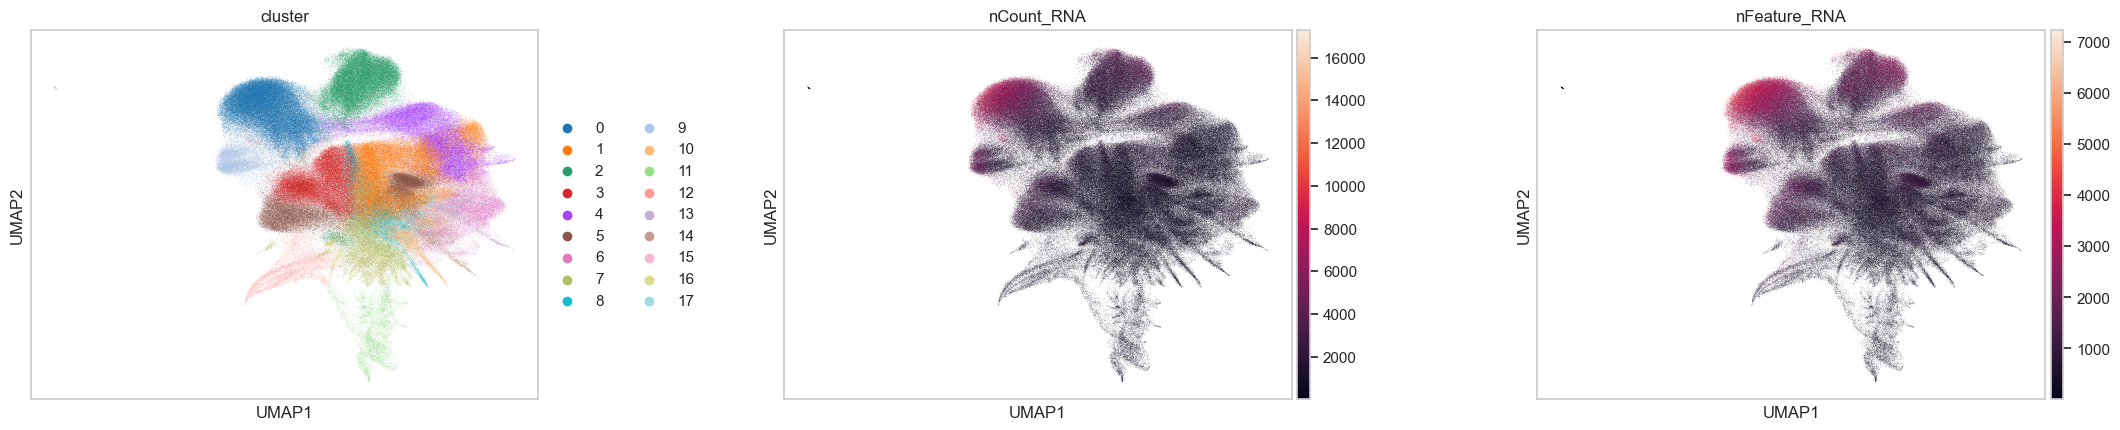

In [16]:
if RUN_ANALYSIS and analysis_adata is not None and "cluster" in analysis_adata.obs:
    sc.pl.umap(analysis_adata, color=["cluster", "nCount_RNA", "nFeature_RNA"], wspace=0.35)
else:
    print("clustered analysis_adata not available for UMAP plotting.")


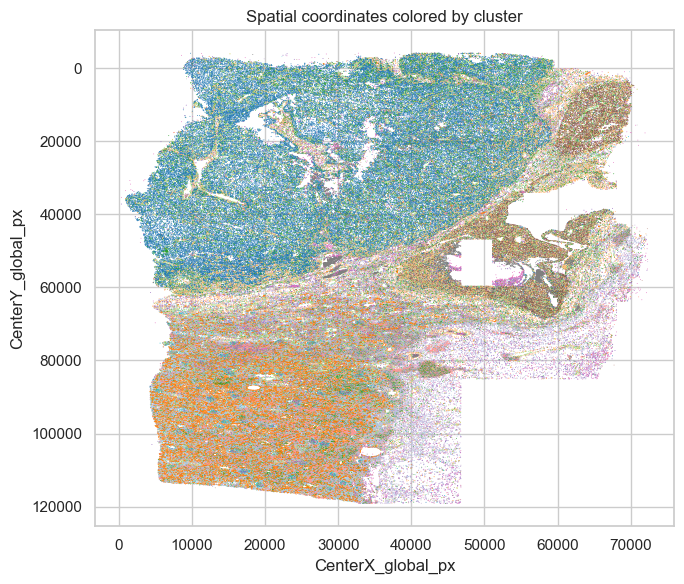

In [17]:
if RUN_ANALYSIS and analysis_adata is not None and "cluster" in analysis_adata.obs:
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(
        analysis_adata.obsm["spatial"][:, 0],
        analysis_adata.obsm["spatial"][:, 1],
        s=0.4,
        c=analysis_adata.obs["cluster"].cat.codes.to_numpy(),
        cmap="tab20",
        linewidths=0,
    )
    ax.set_title("Spatial coordinates colored by cluster")
    ax.set_xlabel("CenterX_global_px")
    ax.set_ylabel("CenterY_global_px")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("clustered analysis_adata not available for spatial plotting.")


## Full export

For the full KaroSpace-ready export:

1. Set `MAX_CELLS = None`.
2. Re-run the build cell.
3. Set `WRITE_OUTPUT = True`.
4. Run the write cell below.


In [20]:
adata.obsm['X_umap'] = analysis_adata.obsm['X_umap']
adata.obs['cluster'] = analysis_adata.obs['cluster']
normalize_total_inplace(adata, target_sum=10_000)
sc.pp.log1p(adata)

In [21]:
adata

AnnData object with n_obs × n_vars = 436787 × 20378
    obs: 'fov', 'slide_ID', 'cell_ID', 'Run_name', 'Run_Tissue_name', 'Panel', 'assay_type', 'sample_id', 'section_id', 'dataset_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 'nFeature_falsecode', 'Area.um2', 'CenterX_global_px', 'CenterY_global_px', 'cluster', 'total_counts_before_normalization', 'normalization_target_sum'
    var: 'feature_name', 'feature_type', 'n_cells_by_counts', 'total_counts'
    uns: 'dataset_source', 'karospace_hints', 'log1p'
    obsm: 'spatial', 'X_umap'

In [22]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if WRITE_OUTPUT:
    adata.write_h5ad(OUTPUT_PATH)
    print(f"Wrote: {OUTPUT_PATH}")
else:
    print("WRITE_OUTPUT is False; notebook is configured for inspection first.")
    print(f"Planned output: {OUTPUT_PATH}")


Wrote: /Users/christoffer/work/karolinska/development/KaroSpaceDataWrangling/notebooks/data/processed/bruker-wtx-kidney/bruker-wtx-kidney.h5ad


In [19]:
karospace_summary = {
    "output_path": str(OUTPUT_PATH),
    "section_key": "section_id",
    "sample_key": "sample_id",
    "spatial_key": "obsm['spatial']",
    "candidate_filter_columns": ["fov", "sample_id", "nCount_RNA", "nFeature_RNA"],
    "obs_columns_retained": EXPORT_OBS_COLUMNS,
    "cluster_method": analysis_adata.uns.get("cluster_method") if "analysis_adata" in globals() and analysis_adata is not None else None,
    "ram_notes": [
        "metadata narrowed with usecols",
        "categorical/string dtypes compacted",
        "expression ingested in chunks",
        "analysis disabled by default",
    ],
}

print(json.dumps(karospace_summary, indent=2))


{
  "output_path": "/Users/christoffer/work/karolinska/development/KaroSpaceDataWrangling/notebooks/data/processed/bruker-wtx-kidney/bruker-wtx-kidney.h5ad",
  "section_key": "section_id",
  "sample_key": "sample_id",
  "spatial_key": "obsm['spatial']",
  "candidate_filter_columns": [
    "fov",
    "sample_id",
    "nCount_RNA",
    "nFeature_RNA"
  ],
  "obs_columns_retained": [
    "fov",
    "slide_ID",
    "cell_ID",
    "Run_name",
    "Run_Tissue_name",
    "Panel",
    "assay_type",
    "sample_id",
    "section_id",
    "dataset_id",
    "nCount_RNA",
    "nFeature_RNA",
    "nCount_negprobes",
    "nFeature_negprobes",
    "nCount_falsecode",
    "nFeature_falsecode",
    "Area.um2",
    "CenterX_global_px",
    "CenterY_global_px"
  ],
  "cluster_method": "leiden_0.6",
  "ram_notes": [
    "metadata narrowed with usecols",
    "categorical/string dtypes compacted",
    "expression ingested in chunks",
    "analysis disabled by default"
  ]
}
